# Delta-Neutral Funding Rate Yield Strategy

**Portfolio Construction & Risk Framework for a $10M Crypto Fund**

This notebook outlines a delta-neutral funding rate capture strategy across CEX and DEX venues. The approach is:

1. **Hold spot + short perp** on the same asset to remain market-neutral
2. **Collect perpetual funding payments** from long-biased markets
3. **Allocate across coins and venues** based on net yield after fees, liquidity, and counterparty risk
4. **Manage margin and rebalancing** through systematic triggers

Coins analyzed: SOL, AVAX, DOGE | Venues: Binance, OKX, Bybit, Hyperliquid, Aster

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

## 1. Funding Rate Data

8-hour funding rates sourced from [Coinalyze](https://coinalyze.net) (March 1, 2026). Rates represent the payment from longs to shorts (positive = shorts earn yield).

In [2]:
data = [
    ["SOL", "Binance", .004, "CEX"],
    ["SOL", "OKX", .0038, "CEX"],
    ["SOL", "Bybit", .01, "CEX"],
    ["SOL", "Hyperliquid", -.0001, "DEX"],
    ["SOL", "Aster", .0037, "DEX"],
    ["AVAX", "Binance", .0034, "CEX"],
    ["AVAX", "OKX", .0028, "CEX"],
    ["AVAX", "Bybit", .01, "CEX"],
    ["AVAX", "Hyperliquid", .0085, "DEX"],
    ["AVAX", "Aster", .01, "DEX"],
    ["DOGE", "Binance", .004, "CEX"],
    ["DOGE", "OKX", -.0058, "CEX"],
    ["DOGE", "Bybit", .008, "CEX"],
    ["DOGE", "Hyperliquid", .0072, "DEX"],
    ["DOGE", "Aster", .0003, "DEX"],
]

df = pd.DataFrame(data, columns=["Coin", "Exchange", "Rate_8h", "Type"])
df["Rate_8h_pct"] = df["Rate_8h"].apply(lambda x: f"{x:.4%}")
print(df[["Coin", "Exchange", "Rate_8h_pct", "Type"]].to_string(index=False))
df = df.drop(columns=["Rate_8h_pct"])

Coin    Exchange Rate_8h_pct Type
 SOL     Binance     0.4000%  CEX
 SOL         OKX     0.3800%  CEX
 SOL       Bybit     1.0000%  CEX
 SOL Hyperliquid    -0.0100%  DEX
 SOL       Aster     0.3700%  DEX
AVAX     Binance     0.3400%  CEX
AVAX         OKX     0.2800%  CEX
AVAX       Bybit     1.0000%  CEX
AVAX Hyperliquid     0.8500%  DEX
AVAX       Aster     1.0000%  DEX
DOGE     Binance     0.4000%  CEX
DOGE         OKX    -0.5800%  CEX
DOGE       Bybit     0.8000%  CEX
DOGE Hyperliquid     0.7200%  DEX
DOGE       Aster     0.0300%  DEX


## 2. Net Yield After Trading Costs

Each delta-neutral position requires 4 trades to enter/exit (buy spot, sell perp, close spot, close perp). Cost model:

| Venue | Maker Fee | Spread (per side) | Round-Trip Cost |
|-------|-----------|-------------------|-----------------|
| CEX (Binance/OKX/Bybit) | 0.02% | 0.01% | 0.10% |
| Hyperliquid | 0.0045% | 0.001% | 0.02% |
| Aster | 0.02% | 0.02% | 0.12% |

Slippage assumed zero using limit orders, iceberg orders, and TWAP execution.

In [3]:
cex_cost = (.02 * 4) + (.01 * 2)      # 4 maker trades + 2 spread crossings
hl_cost = (.0045 * 4) + (.001 * 2)    # Hyperliquid: lower fees
aster_cost = (.02 * 4) + (.02 * 2)    # Aster: wider spreads

df["Annual"] = df["Rate_8h"] * 3 * 365  # 3 funding payments per day

df["Cost"] = df["Exchange"].map({
    "Binance": cex_cost, "OKX": cex_cost, "Bybit": cex_cost,
    "Hyperliquid": hl_cost, "Aster": aster_cost,
})

df["Net_Yield"] = df["Annual"] - df["Cost"]

result = df[["Coin", "Exchange", "Type", "Annual", "Cost", "Net_Yield"]].copy()
for col in ["Annual", "Cost", "Net_Yield"]:
    result[col] = result[col].apply(lambda x: f"{x:.2f}%")
print(result.to_string(index=False))

Coin    Exchange Type Annual  Cost Net_Yield
 SOL     Binance  CEX  4.38% 0.10%     4.28%
 SOL         OKX  CEX  4.16% 0.10%     4.06%
 SOL       Bybit  CEX 10.95% 0.10%    10.85%
 SOL Hyperliquid  DEX -0.11% 0.02%    -0.13%
 SOL       Aster  DEX  4.05% 0.12%     3.93%
AVAX     Binance  CEX  3.72% 0.10%     3.62%
AVAX         OKX  CEX  3.07% 0.10%     2.97%
AVAX       Bybit  CEX 10.95% 0.10%    10.85%
AVAX Hyperliquid  DEX  9.31% 0.02%     9.29%
AVAX       Aster  DEX 10.95% 0.12%    10.83%
DOGE     Binance  CEX  4.38% 0.10%     4.28%
DOGE         OKX  CEX -6.35% 0.10%    -6.45%
DOGE       Bybit  CEX  8.76% 0.10%     8.66%
DOGE Hyperliquid  DEX  7.88% 0.02%     7.86%
DOGE       Aster  DEX  0.33% 0.12%     0.21%


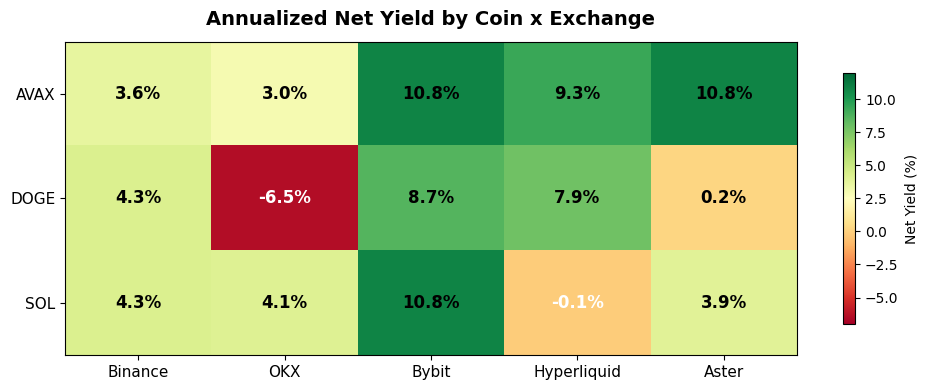

In [4]:
# Net yield heatmap: Coin x Exchange
pivot = df.pivot(index="Coin", columns="Exchange", values="Net_Yield")
pivot = pivot[["Binance", "OKX", "Bybit", "Hyperliquid", "Aster"]]  # order venues

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=-7, vmax=12)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = "white" if val < 0 else "black"
        ax.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=12, fontweight="bold", color=color)

ax.set_title("Annualized Net Yield by Coin x Exchange", fontsize=14, fontweight="bold", pad=12)
plt.colorbar(im, ax=ax, label="Net Yield (%)", shrink=0.8)
plt.tight_layout()
plt.show()

### Coin Selection Rationale

- **SOL**: Highest altcoin OI ($4.8B), tight spreads, available on all major exchanges, most liquid altcoin perp market — can size up and exit quickly
- **AVAX**: Strong positive funding across both CEXs and DEXs suggesting persistent long demand. Tight spreads and strong liquidity
- **DOGE**: Strong retail participation, tracks BTC closely so on BTC rallies funding tends to pay strongest. Extremely liquid across exchanges

### Venue Selection

- **Binance, OKX, Bybit** (CEX): Deepest orderbooks, lower fees, more reliable infrastructure
- **Hyperliquid** (primary DEX): Lowest fees, strong liquidity, less likely for liquidity drain
- **Aster** (secondary DEX): Diversification in case Hyperliquid has downtime or negative funding

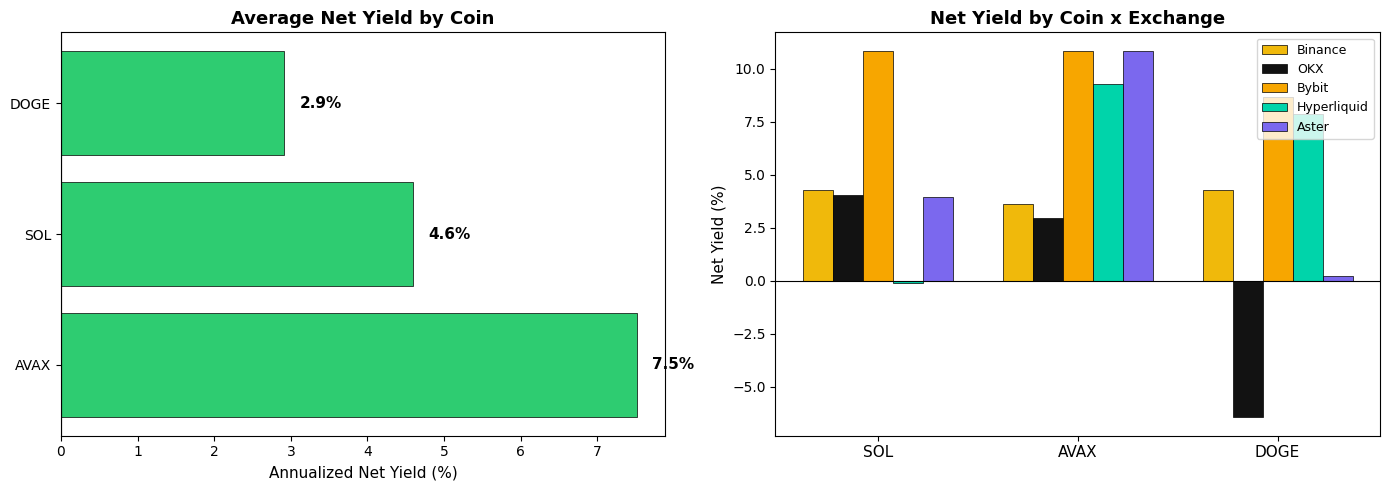

In [5]:
# Average net yield per coin
avg = df.groupby("Coin")["Net_Yield"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: avg yield by coin
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in avg.values]
axes[0].barh(avg.index, avg.values, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Annualized Net Yield (%)", fontsize=11)
axes[0].set_title("Average Net Yield by Coin", fontsize=13, fontweight="bold")
axes[0].axvline(x=0, color="black", linewidth=0.8)
for i, v in enumerate(avg.values):
    axes[0].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=11, fontweight="bold")

# Grouped bar: yield by exchange for each coin
coins = ["SOL", "AVAX", "DOGE"]
exchanges = ["Binance", "OKX", "Bybit", "Hyperliquid", "Aster"]
x = np.arange(len(coins))
width = 0.15
exchange_colors = {"Binance": "#F0B90B", "OKX": "#121212", "Bybit": "#F7A600", 
                   "Hyperliquid": "#00D4AA", "Aster": "#7B68EE"}

for i, ex in enumerate(exchanges):
    vals = [df[(df["Coin"] == c) & (df["Exchange"] == ex)]["Net_Yield"].values[0] for c in coins]
    axes[1].bar(x + i * width, vals, width, label=ex, color=exchange_colors[ex], 
                edgecolor="black", linewidth=0.5)

axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(coins, fontsize=11)
axes[1].set_ylabel("Net Yield (%)", fontsize=11)
axes[1].set_title("Net Yield by Coin x Exchange", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9, loc="upper right")
axes[1].axhline(y=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

## 3. Portfolio Allocation

Portfolio is designed around liquidity to reallocate quickly — highest yield gets largest allocation.

### SOL — 35% ($3.5M) | OI: $4.8B

Strongest liquidity and decent yield. Acts as the flexible part of the portfolio — can easily add allocation when another coin's yield drops.

| Exchange | Weight | Rationale |
|----------|--------|-----------|
| Binance | 35% | Deepest OI, maintain large allocation for liquidity |
| Bybit | 40% | Best yield, still liquid enough to justify large allocation |
| OKX | 15% | Backup venue, diversification |
| Aster | 10% | DEX diversification (Hyperliquid negative yield) |
| Hyperliquid | 0% | Negative funding — skip |

### AVAX — 40% ($4.0M) | OI: $370M

Highest yield. Expect Bybit max funding to mean-revert, but capturing it while it lasts. 40% allocation is >1% of total OI — enter via TWAP over 24-48 hours to avoid price impact.

| Exchange | Weight | Rationale |
|----------|--------|-----------|
| Binance | 35% | Deepest OI, maintain large total Binance allocation |
| Bybit | 35% | Best yield at 10.8% |
| OKX | 15% | Diversification |
| Hyperliquid | 15% | Strong yield on most liquid DEX |
| Aster | 0% | Backup only, OI too thin |

### DOGE — 25% ($2.5M) | OI: $900M

BTC correlation creates potential for higher yield during rallies. Smallest allocation due to lowest current yield.

| Exchange | Weight | Rationale |
|----------|--------|-----------|
| Binance | 40% | Deepest OI |
| Bybit | 35% | Best yield |
| Hyperliquid | 25% | Liquid enough to exit quickly |
| OKX | 0% | Negative funding |
| Aster | 0% | Negative yield |

**Total DEX exposure:** SOL Aster $350K + AVAX Hyperliquid $600K + DOGE Hyperliquid $500K = **$1.45M (14.5%)** — well under the 35% cap.

All 3 coins have 30-day volatility of 25-34%, requiring larger margin buffers. AVAX has highest yield but thinnest OI, so slower entry is acceptable. SOL's lower yield but much higher liquidity allows entry/exit in minutes — that tradeoff is worth it as the flexible component.

### Rebalance Triggers

1. **Funding negative >24h** → Exit coin entirely or move to different exchange
2. **Annualized yield <2.5%** → Reduce weight, rotate to higher-yielding coin
3. **New coin at 2x current yield** → Start rotating 10-20% over 1-3 days (if OI supports it)
4. **OI drops 20% on a venue** → Assume problem, move funds to another venue

**Margin approach:** Cross-margin on Binance and Bybit (winning positions offset losing ones). Isolated margin on DEXs in case of hack.

## 4. Monitoring & Rebalancing Framework

**Daily monitoring checklist:**
- Funding rates per coin per venue — dashboard showing portfolio yield and potential rotations
- Delta per position — has the spot/perp hedge drifted, making one leg larger than the other?
- Unrealized P&L per exchange — is it eating into margin? How close to liquidation on each venue?
- OI changes on any exchange — would it be harder to exit positions?

**Rebalancing cadence:**
- Normal market: rebalance coin weights weekly unless a trigger hits
- Stressed market: monitor hourly, rebalance same day if needed, rotate coins off exchanges

**Rebalance triggers:**

| Trigger | Action |
|---------|--------|
| Funding negative >24h | Exit coin entirely or move to different exchange |
| Annualized yield <2.5% for 24h | Reduce weight, rotate to higher-yielding coin |
| New coin at 2x current yield | Rotate 10-20% of portfolio over 1-3 days (if OI supports it) |
| OI drops 20% on an exchange | Move funds to another venue, accept more slippage if needed |
| Margin utilization hits 50% | Transfer reserves or reduce position size |
| Basis spread widens beyond 0.5% | Stop new entries — something may be wrong on exchange |

**Execution rules:**
- When rotating between coins, do it on the same exchange first to avoid transfer delays
- Close perp position first, always
- Use iceberg orders or TWAPs — target 5-10bps inside best bid/ask with auto-adjustment

## 5. Stress Testing & Margin Analysis

Delta-neutral holds through price moves, but unrealized perp losses eat margin. At 5x leverage, a 20% spike consumes 100% of posted margin.

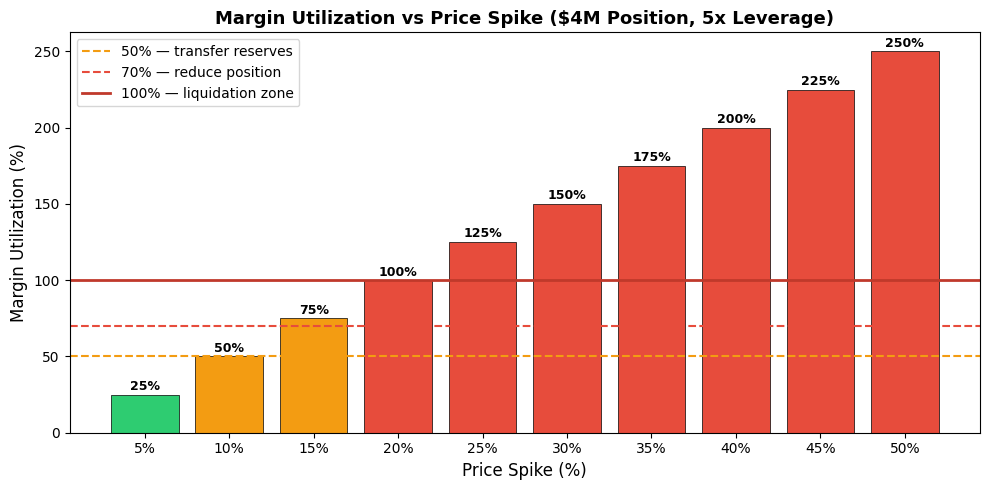


Key thresholds:
  20% spike → 100% margin used → LIQUIDATION RISK
  50% spike → $2,000,000 unrealized loss, 250% margin used


In [6]:
# Stress test: margin utilization across price spike scenarios
# Assuming 5x leverage → $800K margin per $4M position

position = 4_000_000
margin = 800_000
spikes = np.arange(0.05, 0.55, 0.05)

fig, ax = plt.subplots(figsize=(10, 5))
margin_used = [(position * s) / margin * 100 for s in spikes]

colors = ["#2ecc71" if m < 50 else "#f39c12" if m < 100 else "#e74c3c" for m in margin_used]
bars = ax.bar([f"{int(s*100)}%" for s in spikes], margin_used, color=colors, edgecolor="black", linewidth=0.5)

ax.axhline(y=50, color="#f39c12", linestyle="--", linewidth=1.5, label="50% — transfer reserves")
ax.axhline(y=70, color="#e74c3c", linestyle="--", linewidth=1.5, label="70% — reduce position")
ax.axhline(y=100, color="#c0392b", linestyle="-", linewidth=2, label="100% — liquidation zone")

ax.set_xlabel("Price Spike (%)", fontsize=12)
ax.set_ylabel("Margin Utilization (%)", fontsize=12)
ax.set_title("Margin Utilization vs Price Spike ($4M Position, 5x Leverage)", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)

for bar, pct in zip(bars, margin_used):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, f"{pct:.0f}%", 
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nKey thresholds:")
print(f"  20% spike → {position * 0.2 / margin:.0%} margin used → LIQUIDATION RISK")
print(f"  50% spike → ${position * 0.5:,.0f} unrealized loss, {position * 0.5 / margin:.0%} margin used")

### Crisis Playbook

**Margin escalation protocol:**

| Margin Utilization | Action |
|-------------------|--------|
| 50% | Transfer USDC reserves to the exchange |
| 70% (reserves deployed) | Reduce position — sell spot to free cash for perp margin. Ideally sell spot of a non-spiking coin on the same exchange. Break delta-neutral temporarily on the smaller position. DOGE works well here due to cross-exchange liquidity |
| All 3 coins spiking | Protect the largest position first. Close DOGE entirely if needed to free margin |
| Unrealized perp loss >25% of total margin | Trim lowest-yielding position first to prevent cascade |

**DEX failure scenario (Hyperliquid down, $1.1M exposed):**
- Can't close the DEX perp → sell matching spot on a CEX to flatten delta
- Accept the trapped position, wait for DEX recovery
- Early warnings: decreasing OI, large sells on single exchange, noticeable basis divergence

**General rules:**
- Funding flips negative during a spike (likely DEX issue) → close that leg immediately
- Basis spread widens past 0.5% on any exchange → stop all new entries
- Price alerts at every 10% move on all portfolio coins
- Any exchange shows forced deleveraging → reduce exposure immediately, even at a loss

In [7]:
# Yield threshold check — reduce if annualized yield falls below 2.5%
YIELD_THRESHOLD = 0.0025  # 2.5% annualized = 0.25% per 8h funding

rates = {"SOL": .004, "AVAX": .0034, "DOGE": .004}
for coin, rate in rates.items():
    annual = rate * 3 * 365
    status = "HOLD" if rate > YIELD_THRESHOLD else "REDUCE"
    color = "\033[92m" if status == "HOLD" else "\033[91m"
    print(f"  {coin}: {rate:.4%} per 8h ({annual:.1%} annual) — {status}")

  SOL: 0.4000% per 8h (438.0% annual) — HOLD
  AVAX: 0.3400% per 8h (372.3% annual) — HOLD
  DOGE: 0.4000% per 8h (438.0% annual) — HOLD


## 6. Rebalance Signals

In [8]:
# Rank coins by average net yield — check if rebalance is needed
avg = df.groupby("Coin")["Net_Yield"].mean().sort_values(ascending=False)

print("Coin rankings by net yield:")
for coin, yield_pct in avg.items():
    print(f"  {coin}: {yield_pct:.2f}%")

best, worst = avg.max(), avg.min()
if best > worst * 2:
    print(f"\n→ REBALANCE: {avg.idxmax()} yield ({best:.1f}%) is >{2}x {avg.idxmin()} ({worst:.1f}%)")
    print(f"  Action: shift 10% from {avg.idxmin()} to {avg.idxmax()}")
else:
    print("\n→ No rebalance needed — yields are within 2x of each other")

Coin rankings by net yield:
  AVAX: 7.51%
  SOL: 4.60%
  DOGE: 2.91%

→ REBALANCE: AVAX yield (7.5%) is >2x DOGE (2.9%)
  Action: shift 10% from DOGE to AVAX


## 7. Yield Enhancement Ideas

**Liquid staking on the spot leg:** Holding mSOL or sAVAX earns additional yield on top of funding. Limit to ~20% of spot leg to maintain ability to sell quickly for margin. Only worthwhile if borrow rate is below funding yield.

**Cross-exchange funding arbitrage:** If funding gaps are large enough between venues, short perp on the higher-rate exchange and long perp on the lower-rate exchange. Still delta-neutral, captures the inter-exchange spread. More tactical than systematic — doubles exchange exposure and creates withdrawal risk if one venue freezes.

**Covered calls on spot leg:** Selling calls during flat/declining periods collects premium without directional risk. Risk is losing upside on a massive rally and potential illiquidity during a spike when you need to close.

**General rule:** If the extra yield doesn't add at least 2% annualized, it's not worth the added complexity and risk. Protecting capital comes first.